In [44]:

# TensorFlow and tf.keras
import tensorflow as tf
from tensorflow import keras
import h5py 

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt
from keras import regularizers


from sklearn.model_selection import GridSearchCV
from keras.wrappers.scikit_learn import KerasClassifier
from keras.optimizers import Adam

print(tf.__version__)

2.2.0-rc3


Google SVHN Dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3aietf%3awg%3aoauth%3a2.0%3aoob&response_type=code&scope=email%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdocs.test%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive.photos.readonly%20https%3a%2f%2fwww.googleapis.com%2fauth%2fpeopleapi.readonly

Enter your authorization code:
··········
Mounted at /content/drive


In [4]:
h5f= h5py.File('/content/drive/My Drive/Colab Notebooks/SVHN_single_grey1.h5','r')
list(h5f.keys())

['X_test', 'X_train', 'X_val', 'y_test', 'y_train', 'y_val']

In [5]:
X_train=h5f['X_train'][:]
y_train =h5f['y_train'][:]

X_test=h5f['X_test'][:]
y_test =h5f['y_test'][:]

X_val=h5f['X_val'][:]
y_val =h5f['y_val'][:]
h5f.close()

print('Training set', X_train.shape, y_train.shape)
print('Validation set', X_val.shape, y_val.shape)
print('Test set', X_test.shape, y_test.shape)





Training set (42000, 32, 32) (42000,)
Validation set (60000, 32, 32) (60000,)
Test set (18000, 32, 32) (18000,)


Check unique Labels

In [6]:
print(np.unique(y_train))

[0 1 2 3 4 5 6 7 8 9]


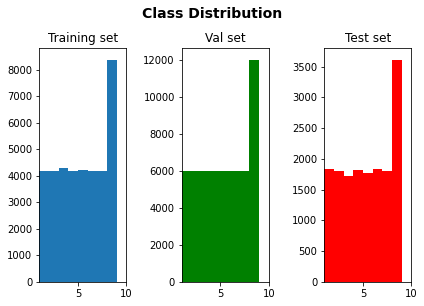

In [7]:
fig, (ax1, ax2,ax3) = plt.subplots(1, 3, sharex=True)

fig.suptitle('Class Distribution', fontsize=14, fontweight='bold', y=1.05)

ax1.hist(y_train, bins=9)
ax1.set_title("Training set")
ax1.set_xlim(1, 10)

ax2.hist(y_val, color='g', bins=9)
ax2.set_title("Val set")

ax3.hist(y_test, color='r', bins=9)
ax3.set_title("Test set")

fig.tight_layout()

The data set skewed towards 9 but otherwise looks like a balanced classification

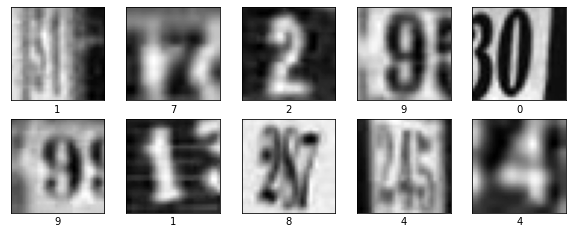

In [8]:
plt.figure(figsize=(10,10))
for i in range(10):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_test[i], cmap=plt.cm.binary)
    plt.xlabel(y_test[i])
plt.show()

In [0]:
X_train = X_train / 255.0

X_test = X_test / 255.0
X_val= X_val / 255.0

In [11]:
y_train

array([2, 6, 7, ..., 7, 0, 4], dtype=uint8)

In [189]:
def create_model():
	# create model
	model = keras.Sequential([
    keras.layers.Flatten(input_shape=(32, 32)),
    keras.layers.BatchNormalization(),
    #keras.layers.Dense(512, activation='relu'),
   # keras.layers.BatchNormalization(),
    #keras.layers.Dropout(0.3),
    keras.layers.Dense(256, activation='relu'),
    #keras.layers.Dropout(0.3),
    #keras.layers.Dropout(0.3),
    #keras.layers.BatchNormalization(),
    keras.layers.Dense(128, activation='relu'),
    #keras.layers.BatchNormalization(),
    keras.layers.Dense(64, activation='relu'),
    #keras.layers.BatchNormalization(),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(10,activation='softmax')])
	# Compile model
	model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
	return model



# create model
model = KerasClassifier(build_fn=create_model, verbose=0)
# define the grid search parameters
batch_size = [500]
epochs = [150,175]
param_grid = dict(batch_size=batch_size, epochs=epochs)
grid = GridSearchCV(estimator=model, param_grid=param_grid, n_jobs=-1, cv=3)
grid_result = grid.fit(X_train, y_train)
# summarize results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Best: 0.797929 using {'batch_size': 500, 'epochs': 175}
0.772167 (0.034203) with: {'batch_size': 500, 'epochs': 150}
0.797929 (0.037756) with: {'batch_size': 500, 'epochs': 175}


In [0]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(32, 32)),
    keras.layers.BatchNormalization(),
    #keras.layers.Dense(512, activation='relu'),
   # keras.layers.BatchNormalization(),
    #keras.layers.Dropout(0.1),
    #keras.layers.Dense(256, activation='relu'),
    #keras.layers.Dropout(0.3),
    #keras.layers.Dropout(0.3),
    #keras.layers.BatchNormalization(),
    keras.layers.Dense(128, activation='relu'),
    #keras.layers.Dropout(0.1),
    #keras.layers.BatchNormalization(),
    #keras.layers.Dense(64, activation='relu'),
    #keras.layers.BatchNormalization(),
    #keras.layers.Dense(32, activation='relu'),
    #keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(10,activation='softmax')
])

In [0]:

model.compile(optimizer=keras.optimizers.Adam(),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [64]:
history = model.fit(X_train, y_train, epochs=150,batch_size= 500,validation_data=(X_val,y_val)
          )

Epoch 1/150
84/84 [==============================] - 2s 22ms/step - loss: 2.1250 - accuracy: 0.3534 - val_loss: 2.1527 - val_accuracy: 0.4670
Epoch 2/150
84/84 [==============================] - 2s 21ms/step - loss: 1.9411 - accuracy: 0.5430 - val_loss: 2.0035 - val_accuracy: 0.5631
Epoch 3/150
84/84 [==============================] - 2s 21ms/step - loss: 1.9008 - accuracy: 0.5754 - val_loss: 1.9281 - val_accuracy: 0.5836
Epoch 4/150
84/84 [==============================] - 2s 21ms/step - loss: 1.8813 - accuracy: 0.5917 - val_loss: 1.8853 - val_accuracy: 0.6029
Epoch 5/150
84/84 [==============================] - 2s 21ms/step - loss: 1.8659 - accuracy: 0.6056 - val_loss: 1.8534 - val_accuracy: 0.6270
Epoch 6/150
84/84 [==============================] - 2s 21ms/step - loss: 1.8324 - accuracy: 0.6412 - val_loss: 1.8262 - val_accuracy: 0.6470
Epoch 7/150
84/84 [==============================] - 2s 21ms/step - loss: 1.8179 - accuracy: 0.6528 - val_loss: 1.8182 - val_accuracy: 0.6528
Epoch 

In [65]:
test_loss, test_acc = model.evaluate(X_test,  y_test, verbose=2)

print('\nTest accuracy:', test_acc)

563/563 - 1s - loss: 1.6033 - accuracy: 0.8573

Test accuracy: 0.8573333621025085


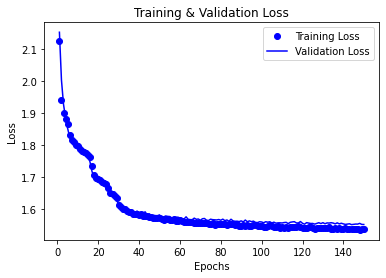

In [66]:
history_dict=history.history
history_dict.keys()
loss_values=history_dict['loss']
val_loss_values=history_dict['val_loss']
epochs= range(1,len(loss_values)+1)
plt.plot(epochs,loss_values,'bo',label='Training Loss')
plt.plot(epochs,val_loss_values,'b',label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

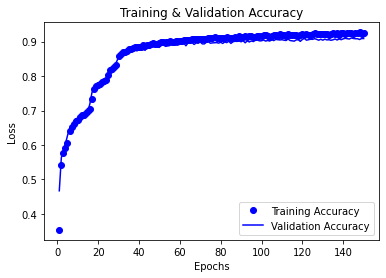

In [68]:
plt.clf()

acc=history_dict['accuracy']
val_acc=history_dict['val_accuracy']

plt.plot(epochs,acc,'bo',label='Training Accuracy')
plt.plot(epochs,val_acc,'b',label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()